In [20]:
from pathlib import Path
from warnings import simplefilter

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

simplefilter("ignore")
plt.rcParams["figure.figsize"] = [15, 4]
sns.set_style('darkgrid')

In [4]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch8')
nyc_taxi = pd.read_csv(path / 'nyc_taxi.csv', index_col='timestamp', parse_dates=True)
nyc_taxi.index.freq = '30T'

<Axes: title={'center': 'NYC Taxi'}, xlabel='timestamp'>

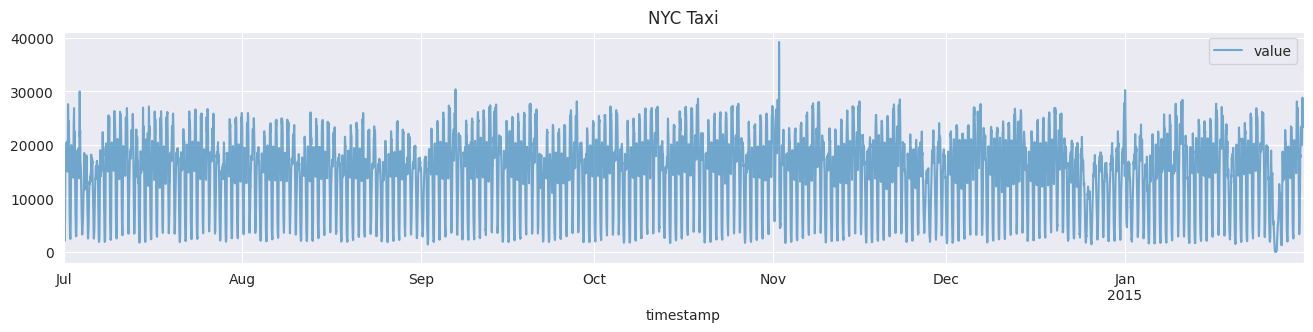

In [6]:
# store the known dates containing outliers, also known as ground truth labels
nyc_dates = [
    "2014-11-01",
    "2014-11-27",
    "2014-12-25",
    "2015-01-01",
    "2015-01-27"
]

# plot the time series data to gt an intuition
nyc_taxi.plot(title="NYC Taxi", alpha=.6)

In [34]:
# create plot_outliers function that will be used later in the recipes
def plot_outliers(outliers, df, method='KNN', halignment='right', valignment='bottom', labels=False):
    '''
    outliers: these are the known outliers dates like holidays
    df: dataframe to check and plot the outliers
    '''
    
    ax = df.plot(alpha=.6)

    if labels:
        for i in outliers['value'].items():
            plt.plot(i[0], i[1], 'rx')
            plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
    else:
        df.loc[outliers.index].plot(ax=ax, style='rx')

    plt.title(f'NYC Taxi - {method}')
    plt.xlabel('date'); plt.ylabel('Number of passengers')
    plt.legend(['nyc taxi', 'outliers'])
    plt.show()

### Understanding outliers
**Domain knowledge** is essential in dealing with outliers. **Non-parametric** statistical methods that do not make assumptions on the underlying distribution. Statistical methods and test based on assumptions of the underlying distribution are called **Parametric methods**

-----------
### Resampling time series data
**Resampling** is changing the frequency or level of granularity of the data. Usually, you will have limited control over how the time series is generated in terms of frequency. For instance, the data can be generated and stored in small intervals, such as
milliseconds, minutes, or hours. In some cases, the data can be in larger intervals, such as
daily, weekly, or monthly.
**Downsampling** is when you can have daily data, but your analysis requires the data to be weekly, and thus you will need to resample.
**Upsampling** is like a situation that requires you to resample your data from daily to hourly.

In [8]:
nyc_taxi.head()

,value
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820


In [9]:
df_downsampled = nyc_taxi.resample('D').mean()    # D for daily, 3B for business days
df_downsampled.head()

,value
timestamp,
2014-07-01,15540.979167
2014-07-02,15284.166667
2014-07-03,14794.625000
2014-07-04,11511.770833
2014-07-05,11572.291667


In [10]:
df_downsampled.index[0]

Timestamp('2014-07-01 00:00:00')

In [11]:
df_downsampled.index.freq

<Day>

In [12]:
df_downsampled.shape

(215, 1)

In [14]:
df_downsampled = nyc_taxi.resample('3D').sum()   # 3 day
df_downsampled.head()

,value
timestamp,
2014-07-01,2189749
2014-07-04,1658320
2014-07-07,2111672
2014-07-10,2335629
2014-07-13,2139711


In [15]:
df_downsampled.index.freq

<3 * Days>

In [16]:
# Lastly let's upsample the data from a 30-minute interval (frequency)
nyc_taxi.resample('15T').mean().head()

,value
timestamp,
2014-07-01 00:00:00,10844.0
2014-07-01 00:15:00,NaN
2014-07-01 00:30:00,8127.0
2014-07-01 00:45:00,NaN
2014-07-01 01:00:00,6210.0


**Note** 
***upsampling*** creates NaN rows. Unlike ***downsampling***, when upsampling,
you need to give instructions on how to fill the NaN rows.

In [17]:
# nyc_taxi.resample('15T').fillna('ffill')
nyc_taxi.resample('15T').ffill()

,value
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:15:00,10844
2014-07-01 00:30:00,8127
2014-07-01 00:45:00,8127
2014-07-01 01:00:00,6210
...,...
2015-01-31 22:30:00,27309
2015-01-31 22:45:00,27309
2015-01-31 23:00:00,26591


In [18]:
nyc_taxi.resample('M').agg(['mean', 'min', 'max', 'median', 'sum'])

value                                
                    mean   min    max   median       sum
timestamp                                               
2014-07-31  14994.084677  1769  29985  16625.5  22311198
2014-08-31  14580.438844  1841  26062  16184.0  21695693
2014-09-30  15623.374306  1431  30373  17244.5  22497659
2014-10-31  16086.851478  1691  28626  17767.5  23937235
2014-11-30  15492.125000  1683  39197  17287.0  22308660
2014-12-31  14813.428763  1459  27804  16587.0  22042382
2015-01-31  14399.790995     8  30236  16061.0  21426889

### Detecting outliers using visualizations

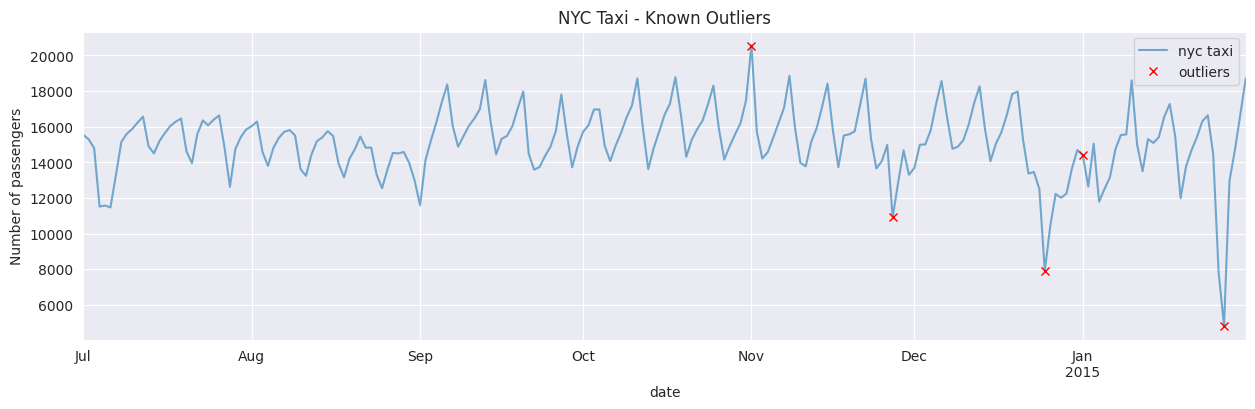

In [21]:
tx = nyc_taxi.resample('D').mean()

known_outliers = tx.loc[nyc_dates]
plot_outliers(known_outliers, tx, 'Known Outliers')

<Axes: ylabel='Count'>

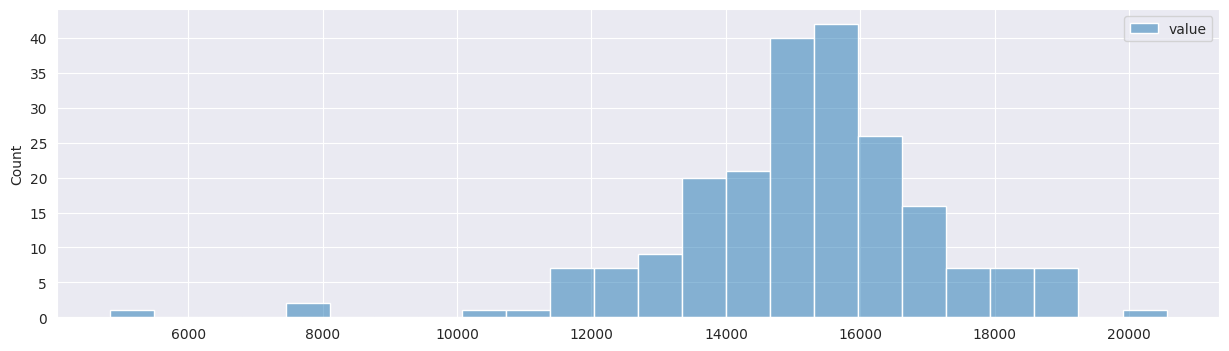

In [22]:
sns.histplot(tx)

The question you should ask yourself if these observations are outliers. The center of the histogram is closde to 15,000 daily average passengers after resampling. This should make you question whether the extreme value close to 20,000 is that extreme. Similarly, the observations with <= 8,000. Again, determining what is an outlier and what is not requires
domain knowledge and further analysis. There is no specific rule, and you will see
throughout this chapter that some of the generally accepted rules are arbitrary and
subjective. You should not jump to conclusions immediately.

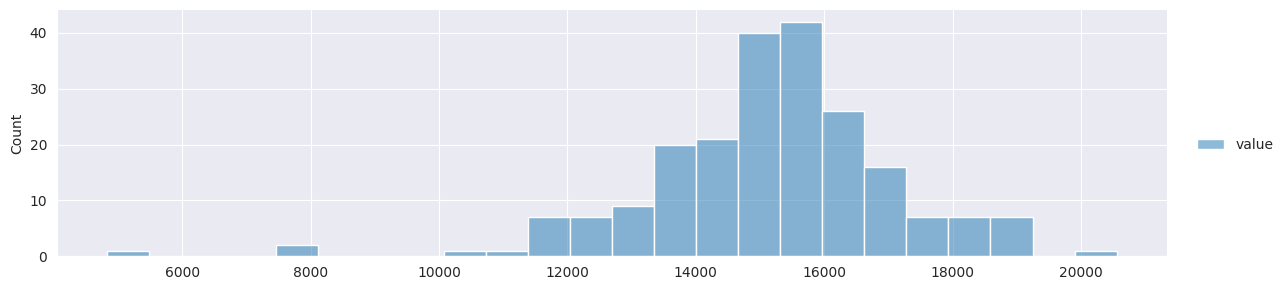

In [23]:
sns.displot(tx, kind='hist', height=3, aspect=4)

Box plot provides more information than histogram and can be a better choice for fro spotting outliers.

<Axes: ylabel='value'>

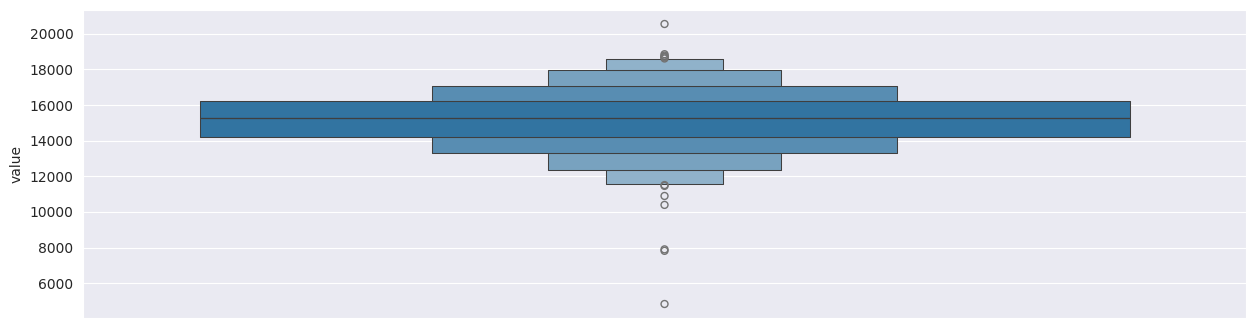

In [24]:
# sns.boxplot(tx['value'])
sns.boxenplot(tx['value'])

<Axes: >

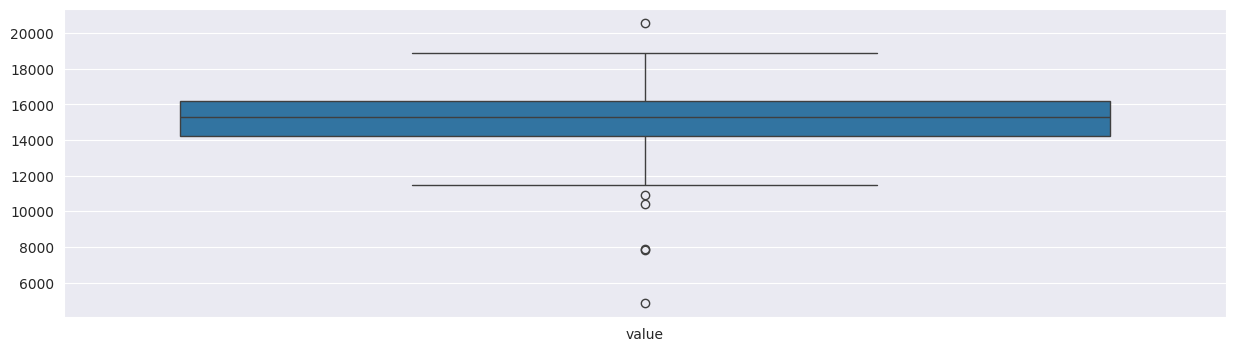

In [26]:
sns.boxplot([tx['value']])

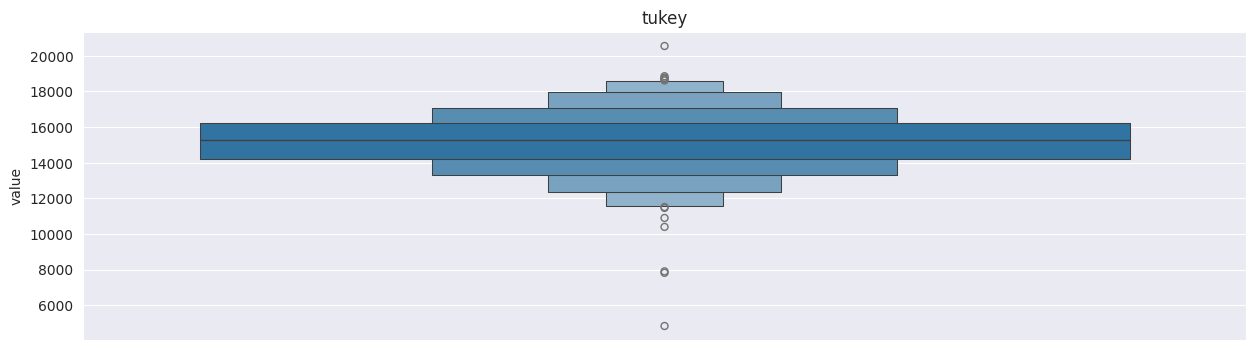

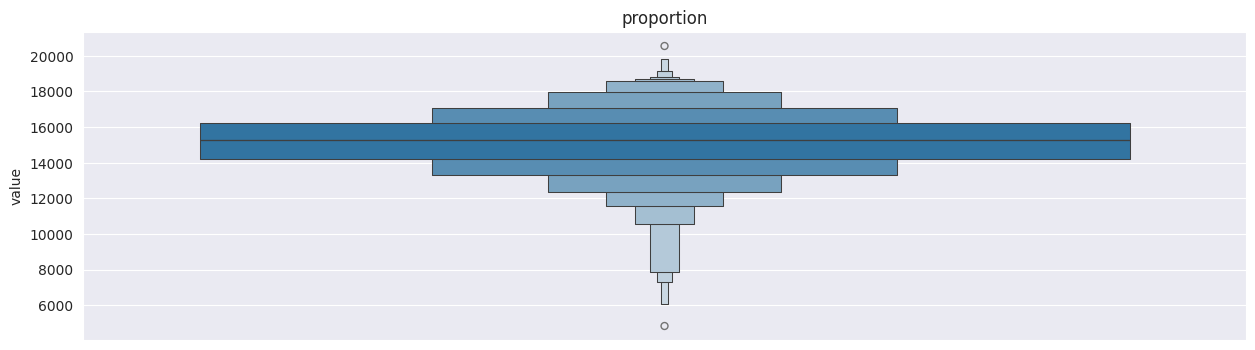

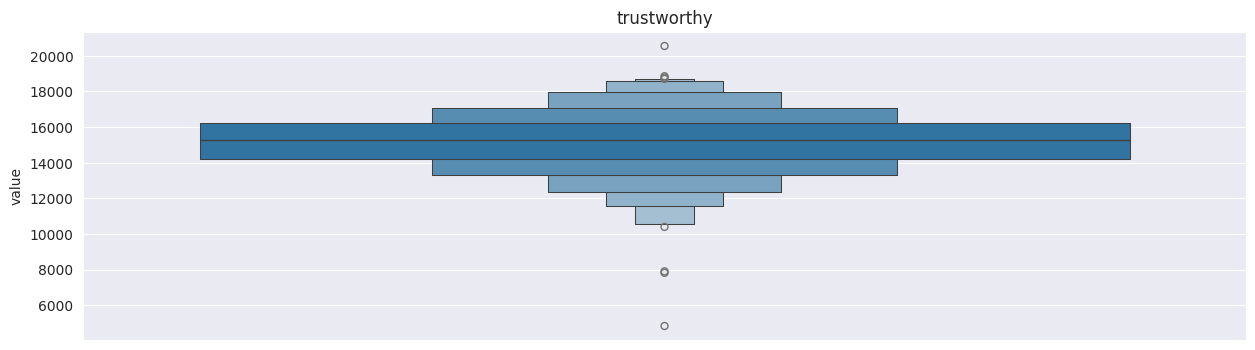

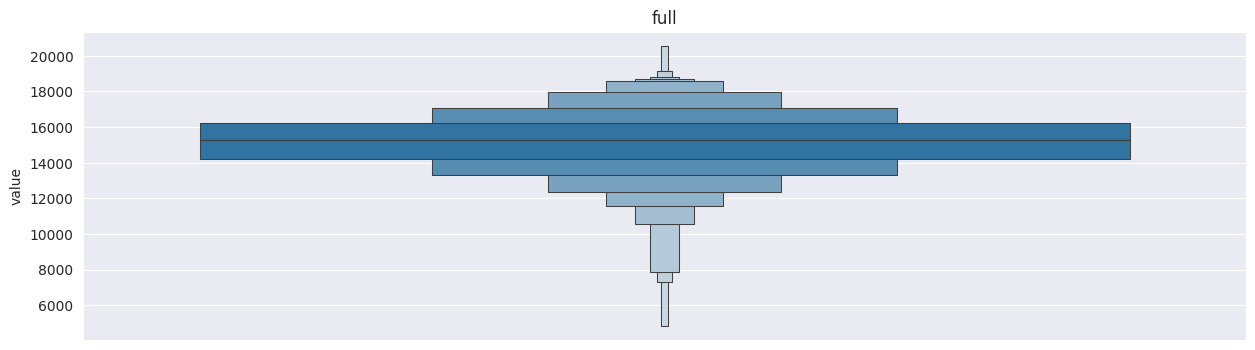

In [27]:
for k in ["tukey", "proportion", "trustworthy", "full"]:
    sns.boxenplot(tx['value'], k_depth=k)
    plt.title(k)
    plt.show()

<Axes: ylabel='value'>

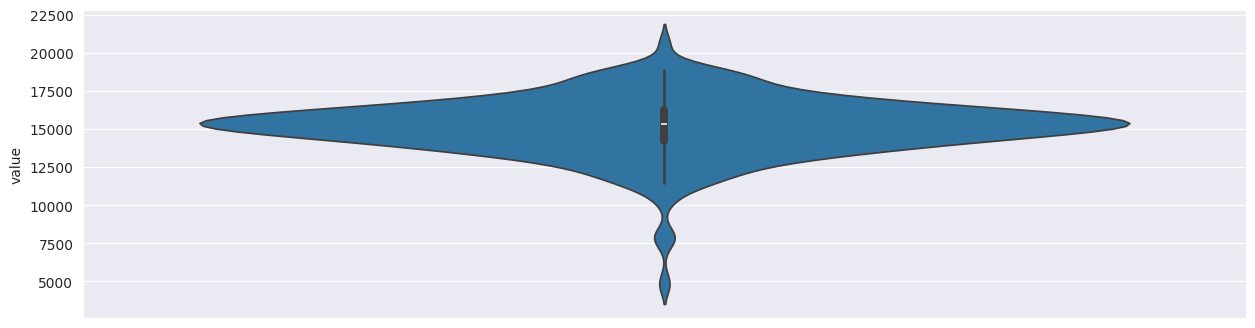

In [28]:
sns.violinplot(tx['value'])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

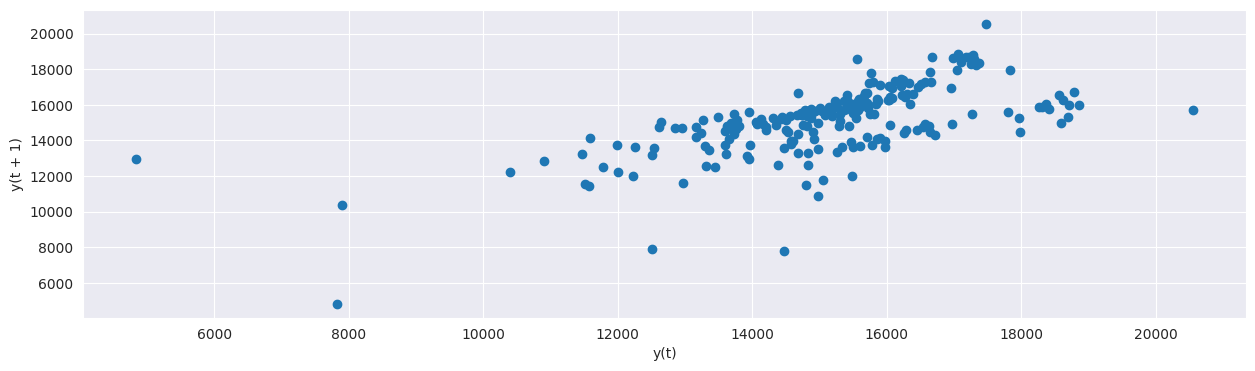

In [29]:
from pandas.plotting import lag_plot
lag_plot(tx)

Further, you can see some linear relationship between the passenger counts and its lagged  version (prior day) indicating the existence of an autocorrelation. Recall from basic statistics that correlation shows the relationship between two independent variables, so you can think of autocorrelation as a correlation of a variable at a time (t) and its prior version at a time (t-1). The labels for the x axis and the y axis in Figure 8.9 can be a bit confusing, with the y axis being labeled as y(t+1). Essentially it is saying the same thing we described earlier: the x axis represents prior values (the predictor) to its future self at t+1, which is what the y axis represents.

<Axes: >

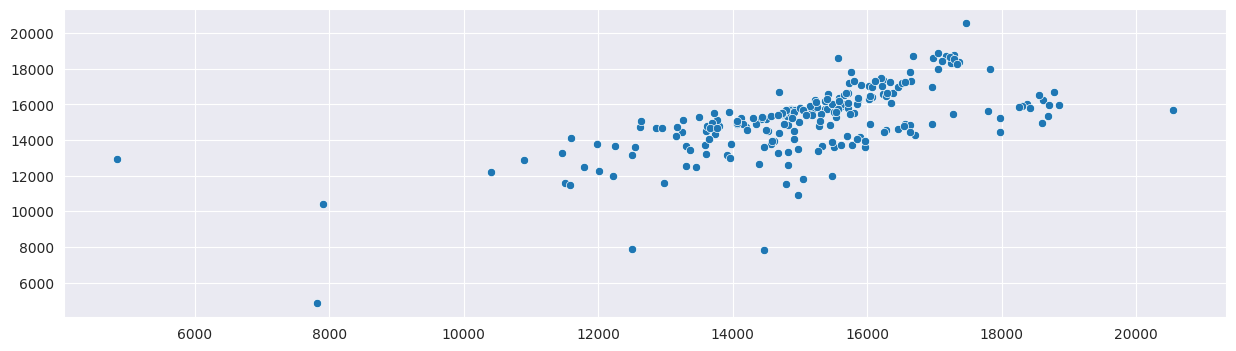

In [32]:
y = tx[1:].values.reshape(-1)
x = tx[:-1].values.reshape(-1)
sns.scatterplot(x=x, y=y)

### Detecting outliers using the Tukey method

In [33]:
percentiles = [0, .05, .1, .25, .5, .75, .90, .95, 1]
tx.describe(percentiles=percentiles)

,value
count,215.000000
mean,15137.569380
std,1937.391020
min,4834.541667
0%,4834.541667
5%,11998.181250
10%,13043.854167
25%,14205.197917
50%,15299.937500
75%,16209.427083


The lower and upper quantiles are known as ***Tukey's fences***

In [35]:
# This function selects all the outliers using interquartile range, 
# all this idea ia coming from box plots
def iqr_outliers(df):
    '''
    df: dataframe
    '''
    q1, q3 = np.percentile(df, [25, 75])
    iqr = q3 - q1
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q1 + (1.5 * iqr)

    return df[(df.value < lower_fence) | (df.value > upper_fence)]

In [36]:
outliers = iqr_outliers(tx)
outliers

,value
timestamp,
2014-09-05,17370.041667
2014-09-06,18369.041667
2014-09-13,18617.729167
2014-09-20,17974.083333
2014-09-27,17801.791667
2014-10-11,18706.416667
2014-10-17,17285.541667
2014-10-18,18778.958333
2014-10-24,17251.791667


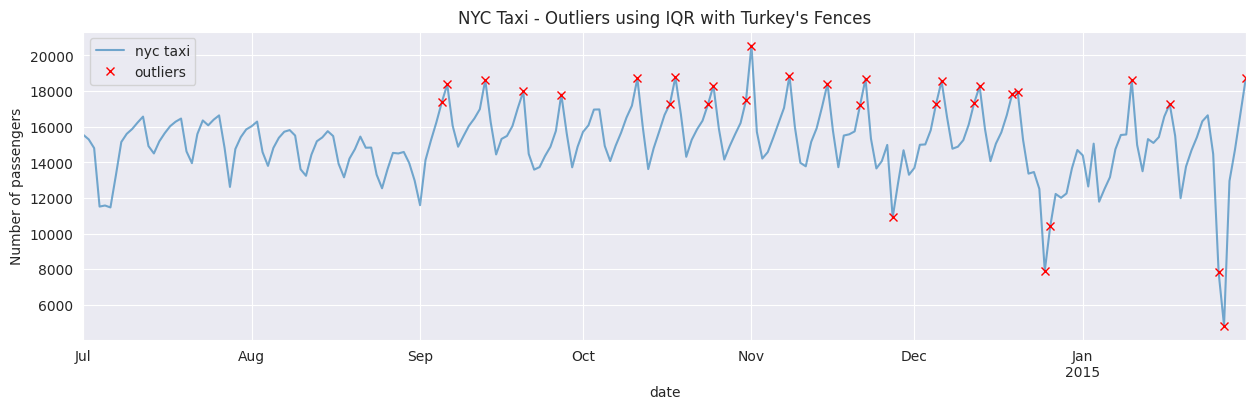

In [37]:
plot_outliers(outliers, tx, "Outliers using IQR with Turkey's Fences")

### Detecting outliers using a z-score